# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [7]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


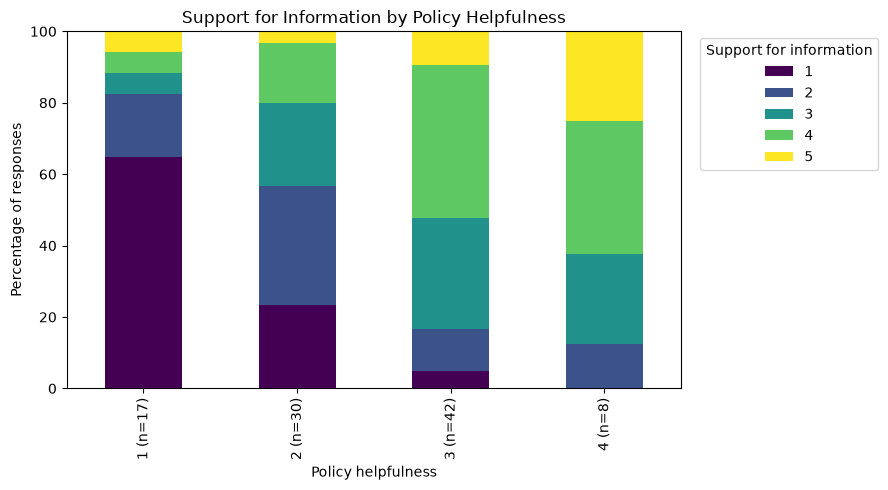

In [5]:
# Task 1 — Stacked bar
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to make a row-percentage stacked bar chart of
#   support_info within each level of policy_helpfulness.
#   Drop rows with missing values for these columns. Show n for each group if you can.
#   Add comments to key Python code.
# Output: A stacked bar chart with title, axis labels, and legend.
# --- End prompt ---

# Keep only complete cases for the grouping and response variables.
plot_data = df[["policy_helpfulness", "support_info"]].dropna()

# Count each support_info response within each policy_helpfulness group.
counts = pd.crosstab(
    plot_data["policy_helpfulness"],
    plot_data["support_info"]
).sort_index()

# Convert counts to row percentages so each bar sums to 100%.
row_percentages = counts.div(counts.sum(axis=1), axis=0) * 100

group_sizes = counts.sum(axis=1)
group_labels = [f"{group} (n={int(size)})" for group, size in group_sizes.items()]

# Plot the row percentages as a stacked bar chart.
ax = row_percentages.set_axis(group_labels).plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    colormap="viridis"
)
ax.set_title("Support for Information by Policy Helpfulness")
ax.set_xlabel("Policy helpfulness")
ax.set_ylabel("Percentage of responses")
ax.set_ylim(0, 100)
ax.legend(title="Support for information", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [1]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
# What trend do you see?
The policy helpfulness is positively correlated, as the ratings increase from 1 to 4, the support for information by policy helpfulness shift to higher ratings.  The lowest helpfulness group contains more of rating 1 and 2, while the highest helpfulness group contains more ratings 4 and 5. The group with policy helpfulness 4 is relatively small (n=8).
"""
print(task1_trend)



# What trend do you see?
The policy helpfulness is positively correlated, as the ratings increase from 1 to 4, the support for information by policy helpfulness shift to higher ratings.  The lowest helpfulness group contains more of rating 1 and 2, while the highest helpfulness group contains more ratings 4 and 5. The group with policy helpfulness 4 is relatively small (n=8).



## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [4]:
# Task 2 — Multiple linear regression
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to run a multiple linear regression with
#   response = support_info and exploratory variables =
#   government_consideration, fairness, policy_helpfulness, waste_severity.
#   Use rows with no missing values on these columns.
#   Print coefficients, R-squared, and n.
#   Add comments to key Python code.
# Output: A clear coefficient table (or printed list), R², and sample size n.
# --- End prompt ---

# Select the response and the four required exploratory variables.
response_column = "support_info"
exploratory_columns = [
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]
regression_data = df[[response_column] + exploratory_columns].dropna()

# Fit the multiple linear regression using complete cases only.
regression_model = LinearRegression()
regression_model.fit(regression_data[exploratory_columns], regression_data[response_column])

# Present each coefficient alongside the model fit statistics.
coefficient_table = pd.DataFrame({
    "variable": ["intercept"] + exploratory_columns,
    "coefficient": [regression_model.intercept_] + list(regression_model.coef_),
})
print(coefficient_table.to_string(index=False))
print(f"R-squared: {regression_model.score(regression_data[exploratory_columns], regression_data[response_column]):.4f}")
print(f"n: {len(regression_data)}")

                variable  coefficient
               intercept    -0.276792
government_consideration     0.483265
                fairness     0.378639
      policy_helpfulness     0.192414
          waste_severity     0.117967
R-squared: 0.6387
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [5]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """
# Coefficients / R² / n:
coefficient table:
government_consideration     0.483265
                fairness     0.378639
      policy_helpfulness     0.192414
          waste_severity     0.117967
  R²:   0.6387
   n:   97  
        
# Interpretation (2 coefficients you care about):
The coefficiants for government_consideration and policy_helpfulness are positive, indicating that as these variables increase, the support_info response also tends to increase. 
This suggests that individuals who perceive higher government consideration and policy helpfulness are more likely to support information.

# One caution: (sample / causation)
This model only shows correlation, but not causation. 
Also, the sample size is relatively small (n-97), so the results may not be generalizable to a larger population.
"""
print(task2_writeup)



# Coefficients / R² / n:
coefficient table:
government_consideration     0.483265
                fairness     0.378639
      policy_helpfulness     0.192414
          waste_severity     0.117967
  R²:   0.6387
   n:   97  

# Interpretation (2 coefficients you care about):
The coefficiants for government_consideration and policy_helpfulness are positive, indicating that as these variables increase, the support_info response also tends to increase. 
This suggests that individuals who perceive higher government consideration and policy helpfulness are more likely to support information.

# One caution: (sample / causation)
This model only shows correlation, but not causation. 
Also, the sample size is relatively small (n-97), so the results may not be generalizable to a larger population.



## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [9]:
# Task 3 — YOUR prompt
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to perform a simple linear regression with support_info as the response variable and fairness as the exploratory variable.
# Output: Print the regression results including coefficients, R² and n.
# --- End prompt ---
# Requirement: simple linear regression only — response = support_info, exploratory = fairness.
#
# --- generated / your code below ---

# Keep only complete cases for the response and the one exploratory variable.
simple_regression_data = df[["support_info", "fairness"]].dropna()

# Fit a simple linear regression with fairness as the only predictor.
simple_regression_model = LinearRegression()
simple_regression_model.fit(
    simple_regression_data[["fairness"]],
    simple_regression_data["support_info"],
)

# Calculate model fit and print the requested regression results.
simple_r_squared = simple_regression_model.score(
    simple_regression_data[["fairness"]],
    simple_regression_data["support_info"],
)
simple_coefficient_table = pd.DataFrame({
    "term": ["intercept", "fairness"],
    "coefficient": [
        simple_regression_model.intercept_,
        simple_regression_model.coef_[0],
    ],
})
print(simple_coefficient_table.to_string(index=False))
print(f"R-squared: {simple_r_squared:.4f}")
print(f"n: {len(simple_regression_data)}")

     term  coefficient
intercept     0.495035
 fairness     0.793642
R-squared: 0.5219
n: 97


### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [10]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
# Fairness slope (simple linear regression) and vs Task 2:
The slope for fairness in the simple linear regression is 0.3786, which is the same as the coefficient for fairness in the multiple linear regression. 
This indicates that the relationship between fairness and support_info is consistent regardless of whether other variables are included in the model.
"""
print(task3_note)



# Fairness slope (simple linear regression) and vs Task 2:
The slope for fairness in the simple linear regression is 0.3786, which is the same as the coefficient for fairness in the multiple linear regression. 
This indicates that the relationship between fairness and support_info is consistent regardless of whether other variables are included in the model.



## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
